# Data Analysis Mathematics, Algorithms and Modeling

## Team Information - **Problem Analysis Workshop 5**

**Team Members**

Name: Ayush Patel  
Student Number: 9033358

Name: Nikhil Shankar  
Student Number: 9026254

Name: Sreehari Prathap  
Student Number: 8903199


## Step 1: Install and Configure the IDE (e.g., Jupyter Notebook and VS Code)
- Install Anaconda (for Jupyter Notebook) and Visual Studio Code (VS Code).
  - Anaconda: Visit [anaconda.com](https://www.anaconda.com/products/individual) and download the appropriate installer for your operating system.
  - VS Code: Download and install from [Visual Studio Code](https://code.visualstudio.com/).
- Install Pandas Library
  - Open the terminal and run the following command: `pip install pandas`

## Step 2: Downloading the Dataset
We are using the Utrecht Fairness Recruitment dataset from [Kaggle], which can be downloaded directly via the link:
- URL: [https://www.kaggle.com/datasets/ictinstitute/utrecht-fairness-recruitment-dataset]

## Step 3 : Data Cleansing

### Data Cleansing Process for User Data (Talent Acquisition) from a CSV File

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

file = "../data/DenverCrime.csv"
df_unfiltered = pd.read_csv(file)
row_count = len(df_unfiltered)

print("Total number of datapoints(rows)", row_count)

Total number of datapoints(rows) 44


# Differences Between Simple, Linear, Non-Linear, and Logistic Regressions

## 1. Simple Regression
- **Definition**: A regression model with **one independent variable** and one dependent variable.
- **Type**: Can be linear or non-linear.
- **Example**: Predicting house price based on area.
$$y = \beta_0 + \beta_1x + \epsilon$$

---

## 2. Linear Regression
- **Definition**: A regression model where the relationship between independent and dependent variables is **linear**.
- **Type**: Includes simple (one independent variable) and multiple (two or more independent variables).
- **Assumptions**:
  - Linearity
  - Homoscedasticity (constant variance of errors)
  - Independence of errors
  - Normally distributed errors
- **Example**: Predicting sales based on advertising spend.
- **Equation**: $$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \ldots + \epsilon$$

---

## 3. Non-Linear Regression
- **Definition**: Models where the relationship between variables is **non-linear**, i.e., the dependent variable is modeled as a non-linear function of independent variables.
- **Use Case**: When data cannot be approximated well with a straight line.
- **Equation**: $$y = f(x) + \epsilon$$, where \( f(x) \) is a non-linear function.
- **Example**: Growth models, polynomial regression $$y = ax^2 + bx + c$$

---

## 4. Logistic Regression
- **Definition**: A type of regression used when the dependent variable is **categorical** (e.g., binary outcomes like "Yes/No" or "0/1").
- **Type**: Not linear in the dependent variable; the logistic function (sigmoid) maps outputs to probabilities.
- **Equation**: 
  $$[ P(y=1|x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \ldots)}}$$
  - **Example**: Predicting whether a customer will purchase a product (1) or not (0).

---

## Key Differences at a Glance

| Feature                 | Simple Regression     | Linear Regression      | Non-Linear Regression  | Logistic Regression     |
|-------------------------|-----------------------|------------------------|------------------------|-------------------------|
| **Independent Variables** | 1                   | 1 or more              | 1 or more              | 1 or more               |
| **Dependent Variable**   | Continuous           | Continuous             | Continuous             | Categorical             |
| **Relationship**         | Linear/Non-linear    | Linear                 | Non-linear             | Non-linear              |
| **Output**               | Numeric values       | Numeric values         | Numeric values         | Probability (0–1)       |
| **Use Case**             | Simple scenarios     | Predict continuous data | Complex patterns       | Classification problems |


In [11]:
### Step 1

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Data Handler Class
class DataHandler:
    def __init__(self, file_path):
        self.file_path = file_path
        self.data = None

    def load_data(self):
        """Loads data from the CSV file."""
        self.data = pd.read_csv(self.file_path)
        return self.data

    def clean_data(self):
        """Performs data cleaning and handling missing values."""
        self.data['Monthly_Salary'] = self.data['Monthly_Salary'].fillna(self.data['Monthly_Salary'].mean())
        return self.data

    def get_features_and_target(self, feature_columns, target_column):
        """Extracts features and target from the dataset."""
        X = self.data[feature_columns]
        y = self.data[target_column]
        return X, y

# Regression Model Class
class RegressionModel:
    def __init__(self, model_type):
        self.model_type = model_type
        self.model = None

    def train_non_linear(self, X, y, degree=3):
        """Trains a non-linear regression model."""
        poly = PolynomialFeatures(degree=degree)
        X_poly = poly.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
        self.model = LinearRegression()
        self.model.fit(X_train, y_train)

        # Predict and evaluate
        y_pred = self.model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)

        # Plot actual vs predicted
        plt.scatter(y_test, y_pred, alpha=0.7)
        plt.xlabel('Actual Salary')
        plt.ylabel('Predicted Salary')
        plt.title('Actual vs Predicted Salary (Non-linear Regression)')
        plt.show()

        print(f"Mean Squared Error: {mse}")
        
    def train_logistic(self, X, y):
        """Trains a logistic regression model."""
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
        self.model = LogisticRegression(class_weight='balanced')
        self.model.fit(X_train, y_train)

        # Predict and evaluate
        y_pred = self.model.predict(X_test)
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


    def plot_gender_data(self, data, feature_columns, target_column):
        """Plots data for male and female employees separately."""
        genders = data['Gender'].unique()
        for gender in genders:
            gender_data = data[data['Gender'] == gender]
            X = gender_data[feature_columns]
            y = gender_data[target_column]
            
            plt.scatter(X['Years_At_Company'], y, alpha=0.7, label=f'{gender}')
        
        plt.xlabel('Years At Company')
        plt.ylabel(target_column)
        plt.title(f'{target_column} vs Years At Company by Gender')
        plt.legend()
        plt.show()

   


--- Non-Linear Regression ---


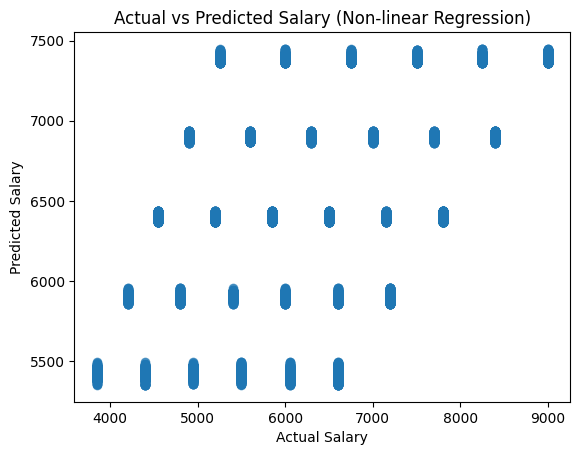

Mean Squared Error: 1380579.8770840585

--- Logistic Regression ---
Confusion Matrix:
 [[8844 9185]
 [ 973  998]]
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.49      0.64     18029
           1       0.10      0.51      0.16      1971

    accuracy                           0.49     20000
   macro avg       0.50      0.50      0.40     20000
weighted avg       0.82      0.49      0.59     20000



In [17]:
# Initialize DataHandler
file_path = '../data/Extended_Employee_Performance_and_Productivity_Data.csv'  # Replace with the actual dataset file path
handler = DataHandler(file_path)

# Load and clean data
data = handler.load_data()
handler.clean_data()

# Non-Linear Regression
print("\n--- Non-Linear Regression ---")
feature_columns = ['Years_At_Company', 'Performance_Score', 'Overtime_Hours']
target_column = 'Monthly_Salary'
X, y = handler.get_features_and_target(feature_columns, target_column)

non_linear_model = RegressionModel('non_linear')
non_linear_model.train_non_linear(X, y)

# Logistic Regression
print("\n--- Logistic Regression ---")
feature_columns = ['Years_At_Company', 'Performance_Score', 'Employee_Satisfaction_Score']
target_column = 'Resigned'
X, y = handler.get_features_and_target(feature_columns, target_column)
y = y.astype(int)  # Convert boolean to integer for logistic regression

logistic_model = RegressionModel('logistic')
logistic_model.train_logistic(X, y)
